In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = pd.read_csv("dataset_synthetic.csv")
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe(include='all'))
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())
df.dropna(inplace=True)
print(df.duplicated().sum())
df = df.drop_duplicates()
print("Total Startups:", len(df))
success_rate = (df['Funding_Success'].value_counts()['Yes'] / len(df)) * 100
print("Funding Success %:", success_rate)
print(df['Funding_Success'].value_counts())

   Startup_ID  Team_Size  Founder_Experience_Years  Startup_Age_Years  \
0           1         19                         3                  9   
1           2         15                        10                  2   
2           3          6                         5                  1   
3           4         20                        13                 10   
4           5          4                         6                  9   

  Industry       City  Funding_Goal  Funding_Raised Funding_Success  \
0  FinTech  Bangalore        665504         1253409             Yes   
1  FinTech  Hyderabad        370346         1473888             Yes   
2  FinTech    Kolkata       1080122          362068              No   
3       AI  Bangalore        413637         2045056             Yes   
4  FinTech  Bangalore       1407287         2380083             Yes   

  Growth_Rate  Revenue  
0        High  5000000  
1        High  5000000  
2         Low   500000  
3        High  5000000  
4        

In [10]:
#phase 2
# Mean
print("Average Team Size:", df["Team_Size"].mean())
print("Average Founder Experience:", df["Founder_Experience_Years"].mean())
print("Average Startup Age:", df["Startup_Age_Years"].mean())

# Median
print("Median Team Size:", df["Team_Size"].median())
print("Median Founder Experience:", df["Founder_Experience_Years"].median())
print("Median Startup Age:", df["Startup_Age_Years"].median())

# Standard Deviation
print("Std Team Size:", df["Team_Size"].std())
print("Std Founder Experience:", df["Founder_Experience_Years"].std())
print("Std Startup Age:", df["Startup_Age_Years"].std())

# Quartiles
print(df[["Team_Size",
          "Founder_Experience_Years",
          "Startup_Age_Years"]].quantile([0.25,0.50,0.75]))

# 90th Percentile
print(df[["Team_Size",
          "Founder_Experience_Years",
          "Startup_Age_Years"]].quantile(0.90))

# Split funded vs non-funded
funded_df = df[df['Funding_Success'] == "Yes"]
nonfunded_df = df[df['Funding_Success'] == "No"]

# Compare averages
print("Average Team Size (Funded):", funded_df['Team_Size'].mean())
print("Average Team Size (Non-Funded):", nonfunded_df['Team_Size'].mean())

print("Average Founder Experience (Funded):", funded_df['Founder_Experience_Years'].mean())
print("Average Founder Experience (Non-Funded):", nonfunded_df['Founder_Experience_Years'].mean())

print("Average Startup Age (Funded):", funded_df['Startup_Age_Years'].mean())
print("Average Startup Age (Non-Funded):", nonfunded_df['Startup_Age_Years'].mean())


Average Team Size: 11.034406881376276
Average Founder Experience: 7.500500100020004
Average Startup Age: 5.498499699939988
Median Team Size: 11.0
Median Founder Experience: 8.0
Median Startup Age: 5.0
Std Team Size: 5.589249707089131
Std Founder Experience: 4.597826198569373
Std Startup Age: 2.8743090318394984
      Team_Size  Founder_Experience_Years  Startup_Age_Years
0.25        6.0                       3.0                3.0
0.50       11.0                       8.0                5.0
0.75       16.0                      11.0                8.0
Team_Size                   19.0
Founder_Experience_Years    14.0
Startup_Age_Years            9.0
Name: 0.9, dtype: float64
Average Team Size (Funded): 10.931772575250836
Average Team Size (Non-Funded): 11.187157789945246
Average Founder Experience (Funded): 7.556521739130435
Average Founder Experience (Non-Funded): 7.4171229467396715
Average Startup Age (Funded): 5.418729096989966
Average Startup Age (Non-Funded): 5.617222498755599


In [13]:
#phase 3
ai_prob = df[df['Industry'] == 'AI']['Funding_Success'].value_counts(normalize=True)
print("Probability that startups get funded:",ai_prob)

exp_prob = df[df['Founder_Experience_Years'] > 5]['Funding_Success'].value_counts(normalize=True)
print("probability that startups with >5 years founder experience get funded:",exp_prob)

city_prob = df.groupby('City')['Funding_Success'].value_counts(normalize=True)
print("Probability of funding by City:",city_prob)


df['Growth_Rate'] = df['Funding_Success'].apply(lambda x:'High' if x=='Yes' else 'Low')

df.to_csv("dataset_synthetic.csv", index=False)

growth_prob = df['Growth_Rate'].value_counts(normalize=True)
print("Probability of funding by Growth Rate:",growth_prob)


Probability that startups get funded: Funding_Success
Yes    0.577548
No     0.422452
Name: proportion, dtype: float64
probability that startups with >5 years founder experience get funded: Funding_Success
Yes    0.599358
No     0.400642
Name: proportion, dtype: float64
Probability of funding by City: City       Funding_Success
Bangalore  Yes                0.634532
           No                 0.365468
Chennai    Yes                0.567568
           No                 0.432432
Delhi      Yes                0.594183
           No                 0.405817
Hyderabad  Yes                0.596639
           No                 0.403361
Kolkata    Yes                0.576981
           No                 0.423019
Mumbai     Yes                0.617918
           No                 0.382082
Pune       Yes                0.598571
           No                 0.401429
Name: proportion, dtype: float64
Probability of funding by Growth Rate: Growth_Rate
High    0.59812
Low     0.40188
Name: pr

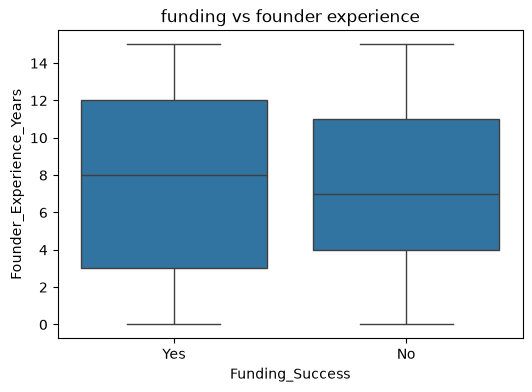

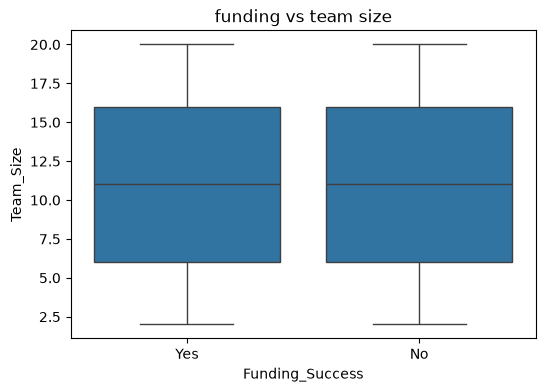

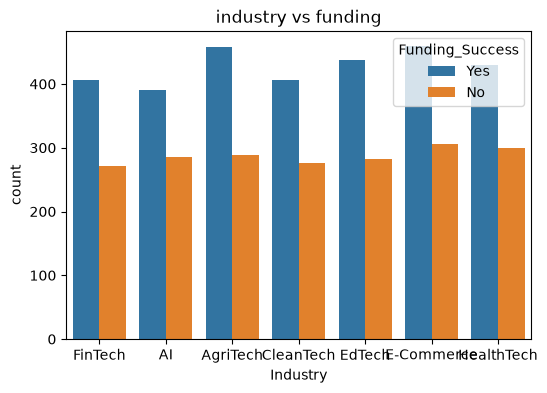

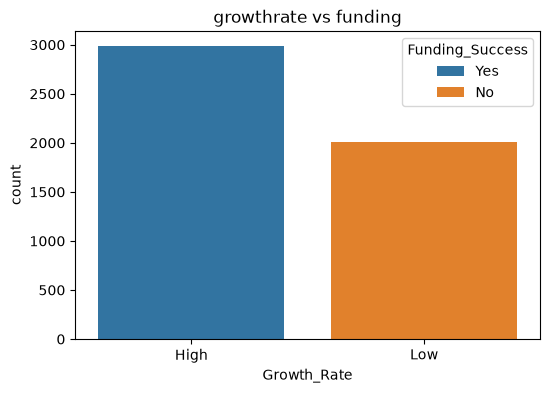

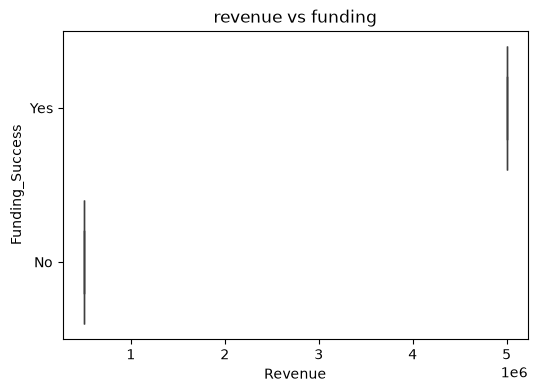

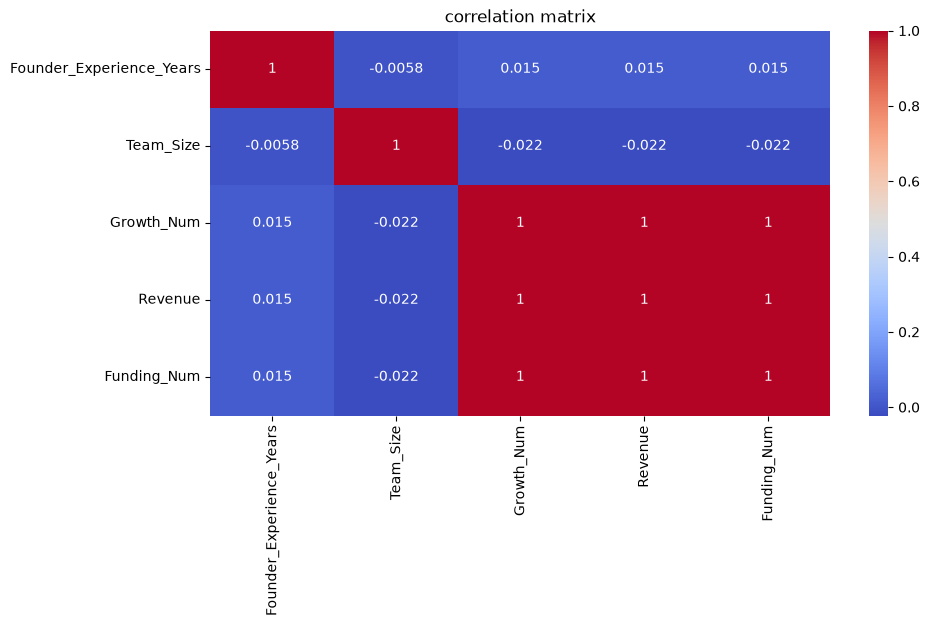

In [14]:
#phase 4
df['Revenue']=df["Funding_Success"].apply(lambda x: 5000000 if x=='Yes' else 500000)
df.to_csv("dataset_synthetic.csv",index=False)
#funding vs founder experience
plt.figure(figsize=(6,4))
sns.boxplot(x='Funding_Success',y='Founder_Experience_Years',data=df)
plt.title("funding vs founder experience")
plt.show()
#funding vs team size
plt.figure(figsize=(6,4))
sns.boxplot(x='Funding_Success',y='Team_Size',data=df)
plt.title("funding vs team size")
plt.show()
#industry vs funding
plt.figure(figsize=(6,4))
sns.countplot(x='Industry',hue='Funding_Success',data=df)
plt.title("industry vs funding")
plt.show()
#growthrate vs funding
plt.figure(figsize=(6,4))
sns.Countplot(x='Growth_Rate',hue='Funding_Success',data=df)
plt.title("growthrate vs funding")
plt.show()
#revenue vs funding
plt.figure(figsize=(6,4))
sns.boxplot(x='Revenue',y='Funding_Success',data=df)
plt.title("revenue vs funding")
plt.show()

#correlation matrix
plt.figure(figsize=(10,5))
df['Funding_Num']=df['Funding_Success'].map({'Yes':1,'No':0})
df['Growth_Num']=df['Growth_Rate'].map({'High':1,'Low':0})
corr=df[['Founder_Experience_Years','Team_Size','Growth_Num','Revenue','Funding_Num']].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

In [15]:
#phase 5
contingency=pd.crosstab(df['Industry'],df['Funding_Success'])
print("Contigency table:\n",contingency)

#run chi square test
chi2, p, dof, expected=stats.chi2_contingency(contingency)
print("chi2\n",chi2)
print("decisionkey\n",p)
print("dof\n",dof)
print("expected frequency\n",expected)
if p < 0.05:
    print("null hypothesis reject(H0),industry Significantly influence funding success")
else:
    print("null hypothesis accepted(H0),Industry significantly does not influence funding success.")   


Contigency table:
 Funding_Success   No  Yes
Industry                 
AI               286  391
AgriTech         288  458
CleanTech        276  407
E-Commerce       306  460
EdTech           282  438
FinTech          272  407
HealthTech       299  429
chi2
 2.554684858868195
decisionkey
 0.8622980584349366
dof
 6
expected frequency
 [[272.0730146  404.9269854 ]
 [299.80276055 446.19723945]
 [274.48429686 408.51570314]
 [307.84036807 458.15963193]
 [289.35387077 430.64612923]
 [272.87677536 406.12322464]
 [292.56891378 435.43108622]]
null hypothesis accepted(H0),Industry significantly does not influence funding success.


In [17]:
#phase 6
df['Category'] = 'other'
df.loc[df['Growth_Rate']=='High', 'Category']='High_Growth'
df.loc[df['Startup_Age_Years']>2,'Category']='Early stage'
df.loc[df['Founder_Experience_Years']<5,'Category']='Experience_Founder'
df.loc[df['Revenue']<100000,'Category']='Revenue_Driven'
df.loc[(df['Revenue']>600000) & (df['Growth_Rate'] == 'Low'),'Category']='High risk startup'

#Success Rate
Success_Rate=df.groupby('Category')['Funding_Num'].mean()*100
print("Success percentage:",Success_Rate)

Success percentage: Category
Early stage            59.509876
Experience_Founder     59.566327
High_Growth           100.000000
other                   0.000000
Name: Funding_Num, dtype: float64


In [2]:
print("\n...phase7...")
print('''

1.Funding factors 
  Total startups 4999, success rate ~59.8%. Funded startups average team size slightly smaller(10.9 vs 11.1) and average startup age higher (5.0 vs 5.5). So **lean teams + slightly mature startups** funding ku advantage.  

2.Industries attracting investment 
  AI startups success probability ~57.7%. EdTech (60.8%), AgriTech (61.4%) and E‑Commerce (60%) also strong. CleanTech + Fin tech comparatively weak. Chi‑square test result: industry influence statistically not significant (Ho accepted), but practically investors prefer AI/AgriTech/EdTech.  

3.Founder advantage
  >5 years experience startups success probability ~59%. Difference small, but experienced founders slightly better. Null hypothesis accept → statistically not strong, but business side la investors still value experience.  

4.High potential segments  
  Segmentation la:  
  - High Growth startups → 100% success
  - Experienced Founder startups → ~59% success  
  - Early stage startups → ~59% success  
  - “Other” → 0% success  
  So High Growth segment maximum potential.  

5.Investor recommendations  
  1. Prioritize **AI, AgriTech, EdTech** industries.  
  2. Focus on **High Growth startups** (clear funding success).  
  3. Prefer **lean teams with moderate age** (5+ years).  
  4. Experienced founders add credibility, though statistical impact is limited.  
  5. Avoid sectors like CleanTech/FinTech unless strong growth signals
  ''')


...phase7...


1.Funding factors 
  Total startups 4999, success rate ~59.8%. Funded startups average team size slightly smaller(10.9 vs 11.1) and average startup age higher (5.0 vs 5.5). So **lean teams + slightly mature startups** funding ku advantage.  

2.Industries attracting investment 
  AI startups success probability ~57.7%. EdTech (60.8%), AgriTech (61.4%) and E‑Commerce (60%) also strong. CleanTech + Fin tech comparatively weak. Chi‑square test result: industry influence statistically not significant (Ho accepted), but practically investors prefer AI/AgriTech/EdTech.  

3.Founder advantage
  >5 years experience startups success probability ~59%. Difference small, but experienced founders slightly better. Null hypothesis accept → statistically not strong, but business side la investors still value experience.  

4.High potential segments  
  Segmentation la:  
  - High Growth startups → 100% success
  - Experienced Founder startups → ~59% success  
  - Early stage startups →

In [16]:
print(type(df))

<class 'pandas.DataFrame'>
